In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv('gold_ml_dataset_2000_2026.csv')

In [3]:
#
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Data ki pehli jhalak
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6391 entries, 2000-10-12 to 2026-04-02
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   final_price       6391 non-null   float64
 1   volume            6391 non-null   float64
 2   rsi               6391 non-null   float64
 3   7d_avg            6391 non-null   float64
 4   30d_avg           6391 non-null   float64
 5   SMA5              6391 non-null   float64
 6   SMA20             6391 non-null   float64
 7   daily_pct_change  6391 non-null   float64
 8   volatility_7d     6391 non-null   float64
 9   momentum_14d      6391 non-null   float64
 10  price_zscore      6391 non-null   float64
 11  trend_signal      6391 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 649.1 KB
None
            final_price  volume        rsi      7d_avg     30d_avg  \
Date                                                                 
2000-10-12   270.50

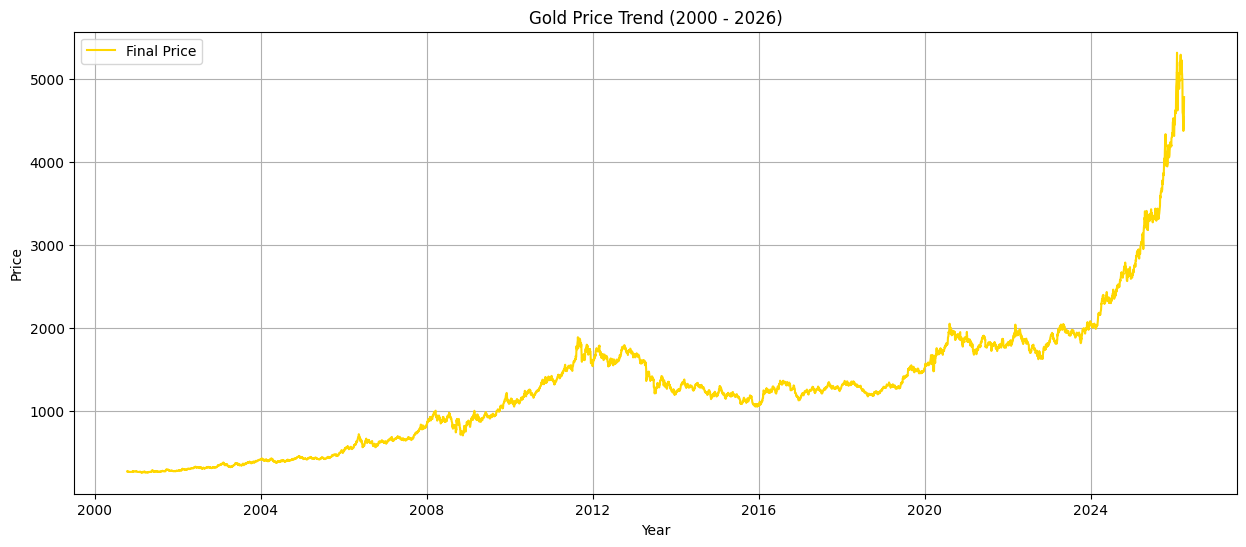

In [4]:
plt.figure(figsize=(15, 6))
plt.plot(df['final_price'], color='gold', label='Final Price')
plt.title('Gold Price Trend (2000 - 2026)')
plt.xlabel('Year')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.savefig('gold_price_trend.png')

### Insights:

#### Gold prices showed a steady increase from 2000 to 2024, followed by a massive and rapid spike reaching over 5000 in 2026.

#### The most significant growth and volatility occurred after 2024, indicating a major shift in market value compared to previous years.

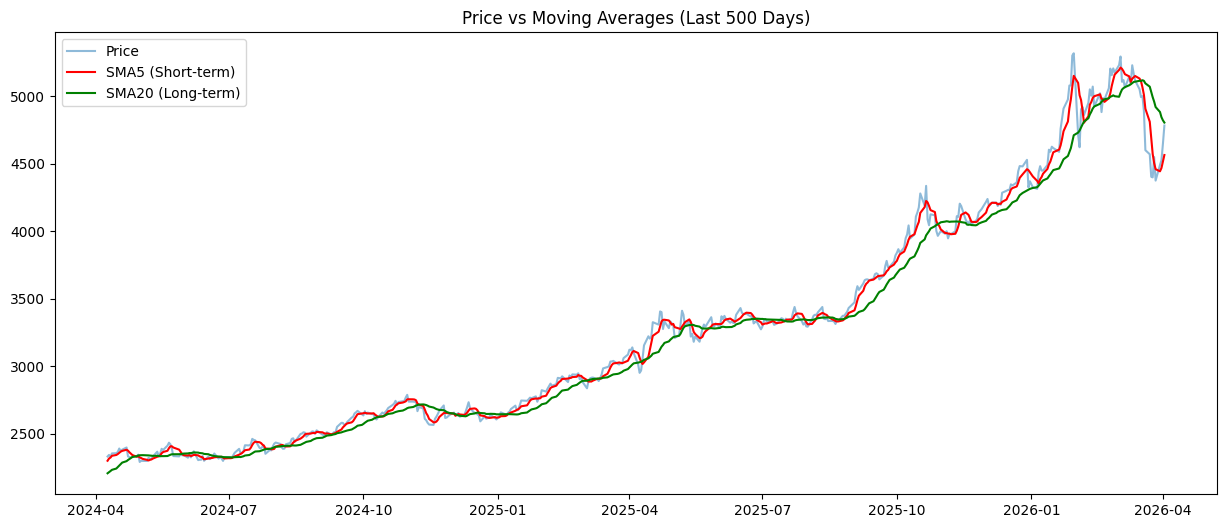

In [5]:
plt.figure(figsize=(15, 6))
plt.plot(df['final_price'].tail(500), label='Price', alpha=0.5) # Sirf last 500 days 
plt.plot(df['SMA5'].tail(500), label='SMA5 (Short-term)', color='red')
plt.plot(df['SMA20'].tail(500), label='SMA20 (Long-term)', color='green')
plt.title('Price vs Moving Averages (Last 500 Days)')
plt.legend()
plt.savefig('moving_averages.png')

### Insights:

#### The chart shows a strong upward trend where the short-term average (SMA5) frequently crosses above the long-term average (SMA20), signaling bullish momentum.

#### Recent data shows high volatility with sharp price fluctuations, but the overall price remains significantly higher than the levels seen in 2024.

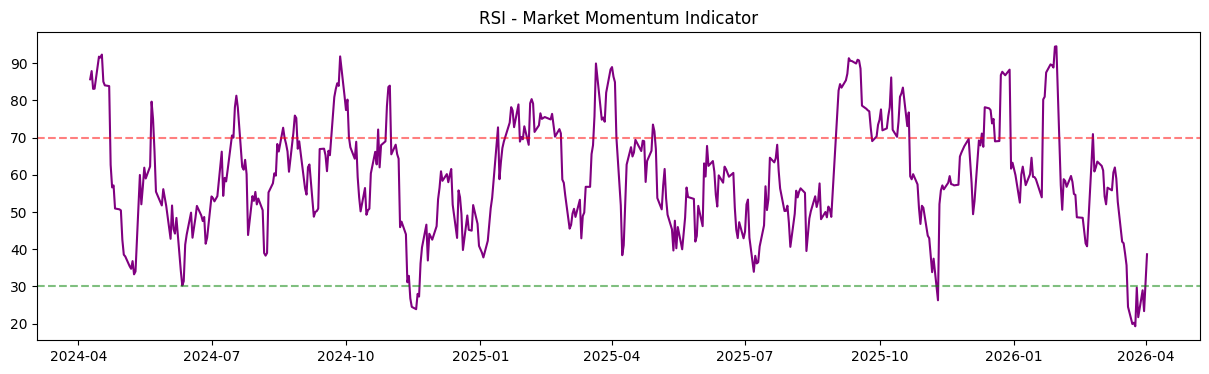

In [6]:
plt.figure(figsize=(15, 4))
plt.plot(df['rsi'].tail(500), color='purple')
plt.axhline(70, linestyle='--', color='red', alpha=0.5) # Overbought line
plt.axhline(30, linestyle='--', color='green', alpha=0.5) # Oversold line
plt.title('RSI - Market Momentum Indicator')
plt.savefig('rsi_analysis.png')

### Insights:

#### The RSI frequently crosses above 70, indicating several periods where the market was overbought and prices were potentially too high.

#### At the end of the graph in 2026, the RSI has dropped below 30, suggesting the market is currently oversold and a price bounce might happen soon.

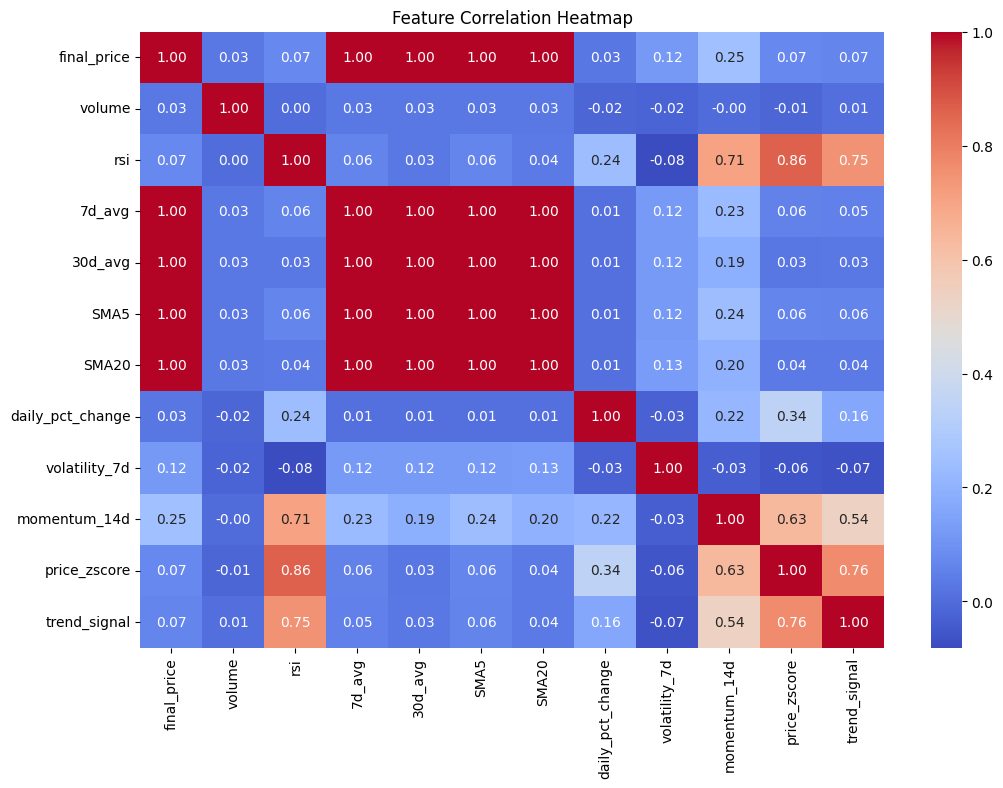

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

### Insights:

#### The 'final_price' is perfectly correlated (1.00) with moving averages like SMA5 and SMA20, meaning they move exactly in the same direction.

#### 'RSI' shows a strong positive correlation with 'trend_signal' and 'price_zscore', suggesting these indicators are very closely linked to market momentum.

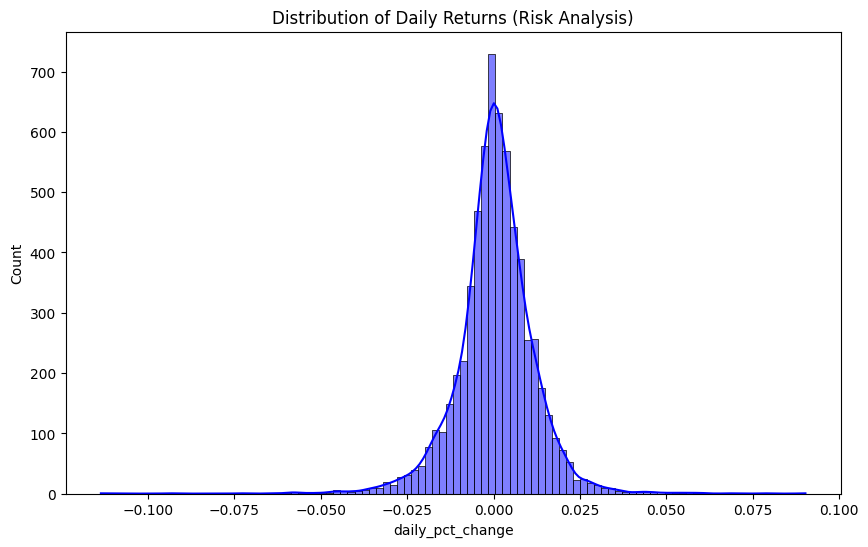

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['daily_pct_change'].dropna(), bins=100, kde=True, color='blue')
plt.title('Distribution of Daily Returns (Risk Analysis)')
plt.savefig('daily_returns.png')

### Insights:

#### Most daily returns are concentrated around 0.00, indicating that the price usually stays stable with very small daily changes.

#### The distribution has long "tails" on both sides, which means there is a risk of occasional large price jumps or drops.